<a href="https://colab.research.google.com/github/Arjun-kumar22/DEEP_Learning/blob/main/Multi_classifications.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [ ]:
df = pd.read_excel("/content/Dry_Bean_Dataset.xlsx")

In [ ]:
df.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [ ]:
df.shape

(13611, 17)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  object 
dtypes: float64(1

In [ ]:
df.describe()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000
mean,53048.284549,855.283459,320.141867,202.270714,1.583242,0.750895,53768.200206,253.064220,0.749733,0.987143,0.873282,0.799864,0.006564,0.001716,0.643590,0.995063
std,29324.095717,214.289696,85.694186,44.970091,0.246678,0.092002,29774.915817,59.177120,0.049086,0.004660,0.059520,0.061713,0.001128,0.000596,0.098996,0.004366
min,20420.000000,524.736000,183.601165,122.512653,1.024868,0.218951,20684.000000,161.243764,0.555315,0.919246,0.489618,0.640577,0.002778,0.000564,0.410339,0.947687
25%,36328.000000,703.523500,253.303633,175.848170,1.432307,0.715928,36714.500000,215.068003,0.718634,0.985670,0.832096,0.762469,0.005900,0.001154,0.581359,0.993703
50%,44652.000000,794.941000,296.883367,192.431733,1.551124,0.764441,45178.000000,238.438026,0.759859,0.988283,0.883157,0.801277,0.006645,0.001694,0.642044,0.996386
75%,61332.000000,977.213000,376.495012,217.031741,1.707109,0.810466,62294.000000,279.446467,0.786851,0.990013,0.916869,0.834270,0.007271,0.002170,0.696006,0.997883
max,254616.000000,1985.370000,738.860153,460.198497,2.430306,0.911423,263261.000000,569.374358,0.866195,0.994677,0.990685,0.987303,0.010451,0.003665,0.974767,0.999733


In [ ]:
df['Class'].value_counts()

,count
Class,
DERMASON,3546
SIRA,2636
SEKER,2027
HOROZ,1928
CALI,1630
BARBUNYA,1322
BOMBAY,522


In [ ]:
df['Class'].nunique()

7

In [ ]:
df.isnull().sum()

,0
Area,0
Perimeter,0
MajorAxisLength,0
MinorAxisLength,0
AspectRation,0
Eccentricity,0
ConvexArea,0
EquivDiameter,0
Extent,0
Solidity,0


In [ ]:
df.isna().sum().sum()

np.int64(0)

In [ ]:
df = df.drop_duplicates()

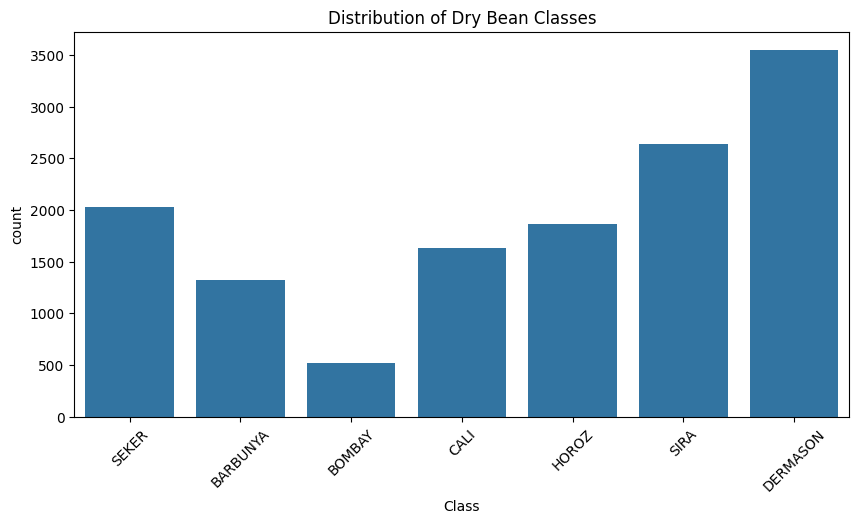

In [ ]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="Class"
)

plt.title("Distribution of Dry Bean Classes")
plt.xticks(rotation=45)
plt.show()

In [ ]:
X = df.drop("Class", axis=1)
y = df["Class"]

In [ ]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (13543, 16)
y shape: (13543,)


In [ ]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

In [ ]:
np.unique(y_encoded)

array([0, 1, 2, 3, 4, 5, 6])

In [ ]:
label_encoder.classes_

array(['BARBUNYA', 'BOMBAY', 'CALI', 'DERMASON', 'HOROZ', 'SEKER', 'SIRA'],
      dtype=object)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [ ]:
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 10834
Testing samples: 2709


In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [ ]:
X_train_scaled = scaler.fit_transform(X_train)

In [ ]:
X_test_scaled = scaler.transform(X_test)

In [ ]:
logistic_model = LogisticRegression(
    max_iter=1000
)

In [ ]:
logistic_model.fit(
    X_train_scaled,
    y_train
)

LogisticRegression(max_iter=1000)

In [ ]:
y_pred_lr = logistic_model.predict(
    X_test_scaled
)

**Evaluate Logistic Regression**

In [ ]:
accuracy_lr = accuracy_score(
    y_test,
    y_pred_lr
)

print("Accuracy:", accuracy_lr)

Accuracy: 0.9191583610188261


In [ ]:
precision_lr = precision_score(
    y_test,
    y_pred_lr,
    average="weighted"
)

print("Precision:", precision_lr)

Precision: 0.9197258462143663


In [ ]:
recall_lr = recall_score(
    y_test,
    y_pred_lr,
    average="weighted"
)

print("Recall:", recall_lr)

Recall: 0.9191583610188261


In [ ]:
f1_lr = f1_score(
    y_test,
    y_pred_lr,
    average="weighted"
)

print("F1-score:", f1_lr)

F1-score: 0.9192902192227252


**Classification Report

Instead of looking at four separate outputs:**

In [ ]:
print(
    classification_report(
        y_test,
        y_pred_lr,
        target_names=label_encoder.classes_
    )
)

              precision    recall  f1-score   support

    BARBUNYA       0.93      0.89      0.91       265
      BOMBAY       1.00      1.00      1.00       104
        CALI       0.91      0.94      0.93       326
    DERMASON       0.93      0.91      0.92       709
       HOROZ       0.96      0.94      0.95       372
       SEKER       0.93      0.94      0.94       406
        SIRA       0.86      0.88      0.87       527

    accuracy                           0.92      2709
   macro avg       0.93      0.93      0.93      2709
weighted avg       0.92      0.92      0.92      2709



**Confusion Matrix**

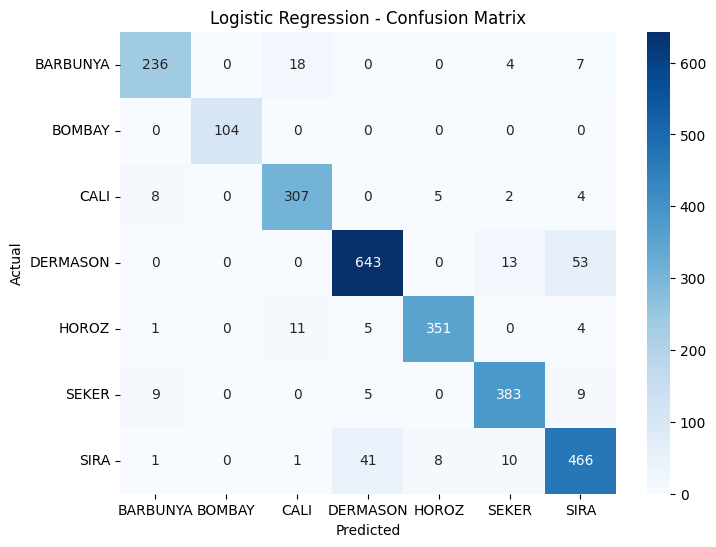

In [ ]:
cm_lr = confusion_matrix(
    y_test,
    y_pred_lr
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression - Confusion Matrix")

plt.show()

**Model 2: Decision Tree**

In [ ]:
dt_model = DecisionTreeClassifier(
    random_state=42
)

In [ ]:
dt_model.fit(
    X_train,
    y_train
)

DecisionTreeClassifier(random_state=42)

In [ ]:
y_pred_dt = dt_model.predict(
    X_test
)

In [ ]:
accuracy_dt = accuracy_score(y_test, y_pred_dt)

precision_dt = precision_score(
    y_test,
    y_pred_dt,
    average="weighted"
)

recall_dt = recall_score(
    y_test,
    y_pred_dt,
    average="weighted"
)

f1_dt = f1_score(
    y_test,
    y_pred_dt,
    average="weighted"
)

print("Accuracy :", accuracy_dt)
print("Precision:", precision_dt)
print("Recall   :", recall_dt)
print("F1-score :", f1_dt)

Accuracy : 0.896640826873385
Precision: 0.8965069451643964
Recall   : 0.896640826873385
F1-score : 0.8964120810013123


**Model 3: Random Forest**

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [ ]:
rf_model.fit(
    X_train,
    y_train
)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred_rf = rf_model.predict(
    X_test
)

In [ ]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)

precision_rf = precision_score(
    y_test,
    y_pred_rf,
    average="weighted"
)

recall_rf = recall_score(
    y_test,
    y_pred_rf,
    average="weighted"
)

f1_rf = f1_score(
    y_test,
    y_pred_rf,
    average="weighted"
)

print("Accuracy :", accuracy_rf)
print("Precision:", precision_rf)
print("Recall   :", recall_rf)
print("F1-score :", f1_rf)

Accuracy : 0.9198966408268734
Precision: 0.9199064064090005
Recall   : 0.9198966408268734
F1-score : 0.9197915837289171


**Final Comparison**

In [ ]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy": [
        accuracy_lr,
        accuracy_dt,
        accuracy_rf
    ],

    "Precision": [
        precision_lr,
        precision_dt,
        precision_rf
    ],

    "Recall": [
        recall_lr,
        recall_dt,
        recall_rf
    ],

    "F1-Score": [
        f1_lr,
        f1_dt,
        f1_rf
    ]
})

results

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.919158,0.919726,0.919158,0.919290
1,Decision Tree,0.896641,0.896507,0.896641,0.896412
2,Random Forest,0.919897,0.919906,0.919897,0.919792


In [ ]:
results.sort_values(
    by="F1-Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1-Score
2,Random Forest,0.919897,0.919906,0.919897,0.919792
0,Logistic Regression,0.919158,0.919726,0.919158,0.919290
1,Decision Tree,0.896641,0.896507,0.896641,0.896412


**Conclusion

The Random Forest model performed best, achieving the highest accuracy (91.99%), precision (91.99%), recall (91.99%), and F1-score (91.98%). Logistic Regression performed very closely, while Decision Tree achieved comparatively lower results. Therefore, Random Forest was the best-performing model for this classification task.**